# Task 1: Convolutional-Recurrent Architecture for Artwork Classification

**ArtExtract — GSoC 2025 Evaluation Task**

---

## Overview

This notebook implements a pipeline for classifying paintings by **Style**, **Artist**, and **Genre** using a **Convolutional-Recurrent (CNN-LSTM)** architecture, trained on the [WikiArt / ArtGAN dataset](https://github.com/cs-chan/ArtGAN/blob/master/WikiArt%20Dataset/README.md).

### Strategy

Paintings are rich visual objects that contain both **local texture patterns** (brushstrokes, colors, composition details) and **global structural cues** (pose of figures, spatial arrangement). A pure CNN captures local features well, but a recurrent layer on top allows the model to integrate spatial context across different regions of the image (treating a grid of CNN-extracted patch features as a sequence).

The chosen approach is:
1. **CNN Backbone** — VGG16 pre-trained on ImageNet, used as a feature extractor.
2. **Sequence formation** — The spatial feature map (H×W grid of feature vectors) is flattened into a sequence of patch embeddings.
3. **Bidirectional LSTM** — Captures long-range dependencies between image regions.
4. **Multi-head classifier** — Three separate classification heads for Style, Artist, and Genre.

### Evaluation Metrics
- **Top-1 / Top-5 Accuracy** — Standard classification accuracy.
- **Macro F1-Score** — Accounts for class imbalance, which is severe in the WikiArt dataset.
- **Confusion Matrix** — To identify which styles/artists are most often confused.

---
## 1. Environment Setup & Library Imports

In [1]:
# ── Core scientific stack ────────────────────────────────────────────────────
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm

# ── PyTorch & torchvision ────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchvision.models import vgg16, VGG16_Weights

# ── Sklearn utilities ────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
)
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

# ── Image loading ────────────────────────────────────────────────────────────
from PIL import Image

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 100
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu126


---
## 2. Dataset: WikiArt / ArtGAN

The [ArtGAN WikiArt dataset](https://github.com/cs-chan/ArtGAN/blob/master/WikiArt%20Dataset/README.md) contains **~80 000 paintings** across:
- **27 Art Styles** (Impressionism, Cubism, Baroque, …)
- **195 Artists** (Monet, Picasso, Rembrandt, …)
- **10 Genres** (portrait, landscape, religious painting, …)

The dataset provides CSV split files (`train.csv`, `val.csv`, `test.csv`) with columns:
`image_path, style_label, artist_label, genre_label`.

Below we define paths and a helper to inspect class distributions.

In [2]:
# ── Dataset paths ─────────────────────────────────────────────────────────────
# Update CSV_ROOT / IMAGE_ROOT to match your local WikiArt extraction layout.
CSV_ROOT = Path("datasets/wikiart/wikiart_csv")
IMAGE_ROOT = Path("datasets/wikiart")
TRAIN_CSV = CSV_ROOT / "train.csv"
VAL_CSV = CSV_ROOT / "val.csv"
TEST_CSV = CSV_ROOT / "test.csv"

# Label columns
STYLE_COL = "style_id"
ARTIST_COL = "artist_id"
GENRE_COL = "genre_id"
IMG_COL = "path_images"

# Hyper-parameters
IMG_SIZE = 224  # resize shorter side to IMG_SIZE
BATCH_SIZE = 128
NUM_EPOCHS = 200
LR = 1e-4
WEIGHT_DECAY = 1e-4
LSTM_HIDDEN = 256
LSTM_LAYERS = 1
NUM_WORKERS = 0  # safer default for Windows/Jupyter

print("Paths configured. Update CSV_ROOT / IMAGE_ROOT if needed.")

Paths configured. Update CSV_ROOT / IMAGE_ROOT if needed.


In [3]:
def load_csv_or_demo(csv_path: Path, demo_rows: int = 200) -> pd.DataFrame:
    """Load split CSV, or return a tiny synthetic demo DataFrame."""
    if csv_path.exists():
        return pd.read_csv(csv_path)
    # ── Demo mode: build a fake DataFrame so the notebook is runnable ─────
    print(f"[DEMO] {csv_path} not found — generating synthetic data.")
    rng = np.random.default_rng(SEED)
    styles = [f"style_{i}" for i in range(10)]
    artists = [f"artist_{i}" for i in range(20)]
    genres = [f"genre_{i}" for i in range(5)]
    return pd.DataFrame(
        {
            IMG_COL: [f"img_{i:05d}.jpg" for i in range(demo_rows)],
            STYLE_COL: rng.choice(styles, demo_rows),
            ARTIST_COL: rng.choice(artists, demo_rows),
            GENRE_COL: rng.choice(genres, demo_rows),
        }
    )


train_df = load_csv_or_demo(TRAIN_CSV)
val_df = load_csv_or_demo(VAL_CSV, demo_rows=50)
test_df = load_csv_or_demo(TEST_CSV, demo_rows=50)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
train_df.head(3)

Train: 12998 | Val: 1625 | Test: 1625


,path_images,artist_id,genre_id,style_id
0,Realism/john-singer-sargent_portrait-of-paulin...,11,6,21
1,Post_Impressionism/vincent-van-gogh_chair-and-...,22,8,20
2,Impressionism/camille-pissarro_seated-shepherd...,2,2,12


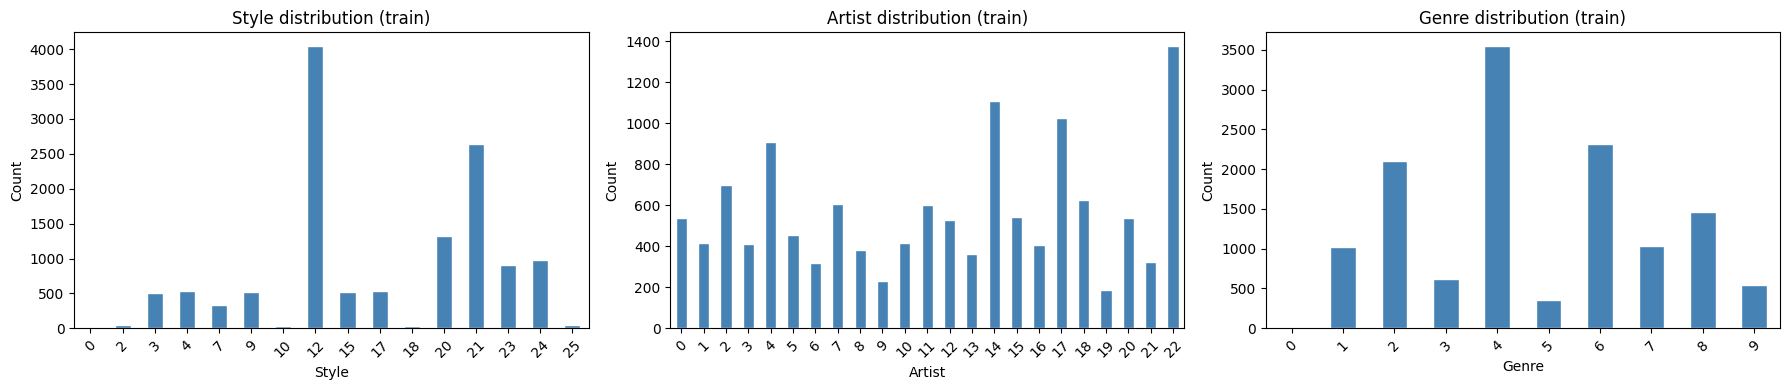

In [4]:
# ── Class distribution ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col, title in zip(
    axes, [STYLE_COL, ARTIST_COL, GENRE_COL], ["Style", "Artist", "Genre"]
):
    counts = train_df[col].value_counts().sort_index()
    counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"{title} distribution (train)")
    ax.set_xlabel(title)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

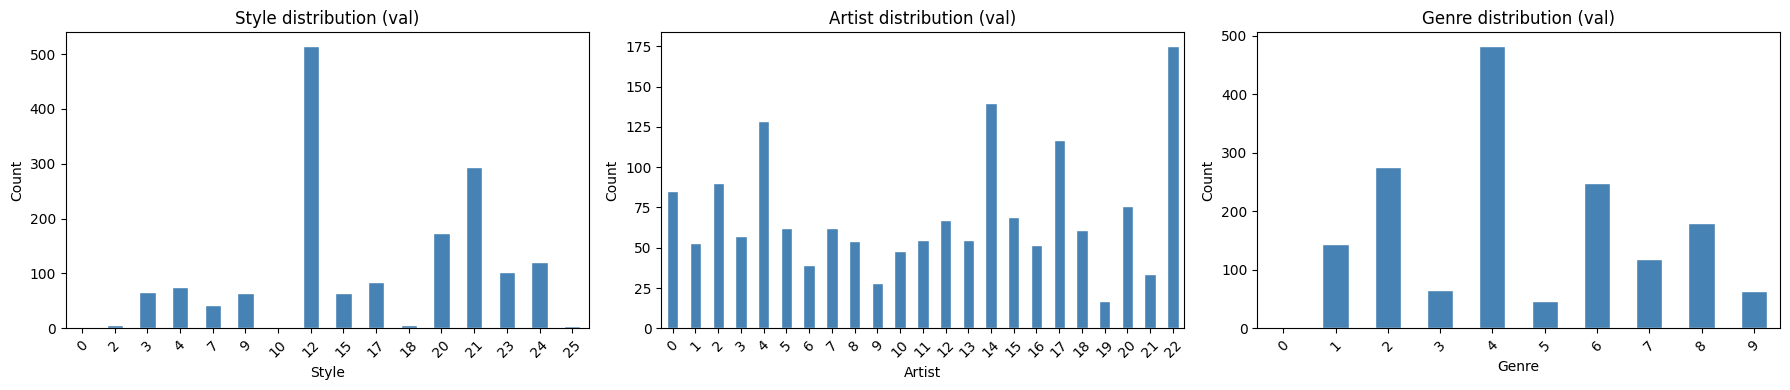

In [5]:
# ── Class distribution ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col, title in zip(
    axes, [STYLE_COL, ARTIST_COL, GENRE_COL], ["Style", "Artist", "Genre"]
):
    counts = val_df[col].value_counts().sort_index()
    counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"{title} distribution (val)")
    ax.set_xlabel(title)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

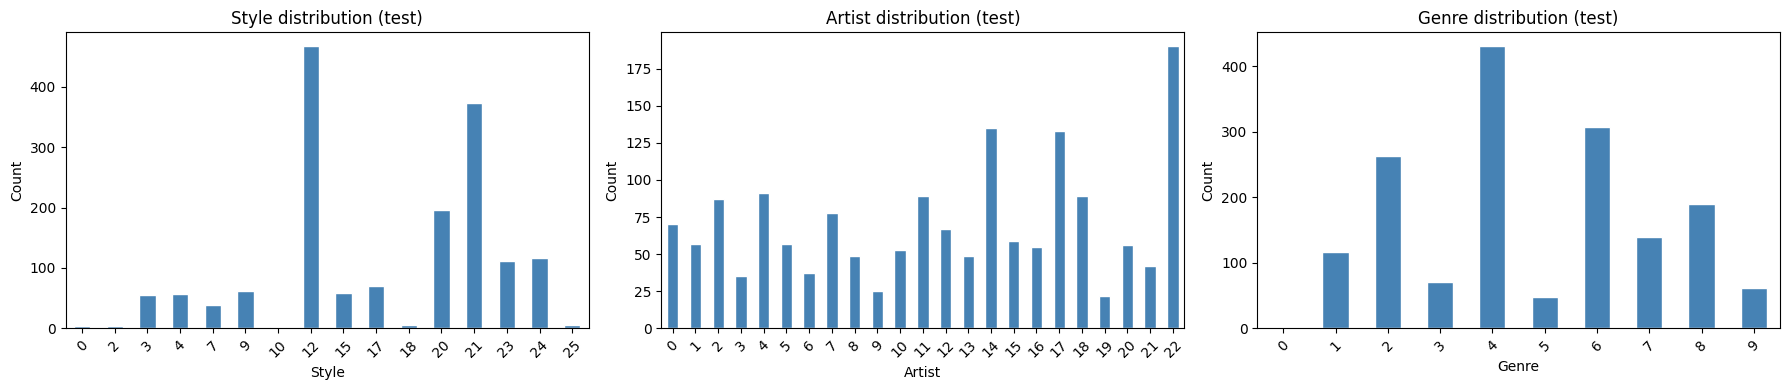

In [6]:
# ── Class distribution ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col, title in zip(
    axes, [STYLE_COL, ARTIST_COL, GENRE_COL], ["Style", "Artist", "Genre"]
):
    counts = test_df[col].value_counts().sort_index()
    counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"{title} distribution (test)")
    ax.set_xlabel(title)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

---
## 3. Data Preprocessing & Augmentation

In [7]:
# ── Label encoding ────────────────────────────────────────────────────────────
le_style = LabelEncoder().fit(train_df[STYLE_COL])
le_artist = LabelEncoder().fit(train_df[ARTIST_COL])
le_genre = LabelEncoder().fit(train_df[GENRE_COL])

NUM_STYLES = len(le_style.classes_)
NUM_ARTISTS = len(le_artist.classes_)
NUM_GENRES = len(le_genre.classes_)
print(
    f"Unique classes — Style: {NUM_STYLES}, Artist: {NUM_ARTISTS}, Genre: {NUM_GENRES}"
)

# ── Transforms ───────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
    ]
)

eval_transforms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

print("Transforms defined.")

Unique classes — Style: 16, Artist: 23, Genre: 10
Transforms defined.


In [8]:
class WikiArtDataset(Dataset):
    """PyTorch Dataset for WikiArt paintings.

    Parameters
    ----------
    df         : DataFrame with columns [IMG_COL, STYLE_COL, ARTIST_COL, GENRE_COL]
    root       : Root directory where images are stored
    transform  : torchvision transforms to apply
    le_style / le_artist / le_genre : fitted LabelEncoders
    demo_mode  : if True, returns a random tensor instead of reading disk images
    """

    def __init__(
        self, df, root, transform, le_style, le_artist, le_genre, demo_mode=False
    ):
        self.df = df.reset_index(drop=True)
        self.root = Path(root)
        self.transform = transform
        self.le_style = le_style
        self.le_artist = le_artist
        self.le_genre = le_genre
        self.demo_mode = demo_mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.demo_mode:
            # Return a random tensor so the pipeline can be tested without images
            image = torch.randn(3, IMG_SIZE, IMG_SIZE)
        else:
            img_path = self.root / row[IMG_COL]
            image = Image.open(img_path).convert("RGB")
            image = self.transform(image)

        style_label = int(self.le_style.transform([row[STYLE_COL]])[0])
        artist_label = int(self.le_artist.transform([row[ARTIST_COL]])[0])
        genre_label = int(self.le_genre.transform([row[GENRE_COL]])[0])

        return image, style_label, artist_label, genre_label


# Detect whether we're in demo mode
csv_files_ok = TRAIN_CSV.exists() and VAL_CSV.exists() and TEST_CSV.exists()
images_ok = (
    IMAGE_ROOT.exists()
    and train_df[IMG_COL].map(lambda p: (IMAGE_ROOT / p).exists()).head(20).all()
)
DEMO = not (csv_files_ok and images_ok)

train_dataset = WikiArtDataset(
    train_df,
    IMAGE_ROOT,
    train_transforms,
    le_style,
    le_artist,
    le_genre,
    demo_mode=DEMO,
)
val_dataset = WikiArtDataset(
    val_df, IMAGE_ROOT, eval_transforms, le_style, le_artist, le_genre, demo_mode=DEMO
)
test_dataset = WikiArtDataset(
    test_df, IMAGE_ROOT, eval_transforms, le_style, le_artist, le_genre, demo_mode=DEMO
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print(f"DataLoaders ready. Demo mode: {DEMO}")

DataLoaders ready. Demo mode: False


---
## 4. Model Architecture — CNN + Bidirectional LSTM

```
Input image (3 × 224 × 224)
       │
  VGG16 backbone
  (remove classification head)     →  feature map  (512 × 7 × 7)
       │
  Reshape to sequence              →  (49 patches × 512 features)
       │
  Bidirectional LSTM (2 layers)    →  (49 × 1024)  last hidden: (1024,)
       │
  ┌────┴────┬────────┐
 Style   Artist   Genre
 head     head    head
```

Each classification head is a two-layer MLP with dropout and batch-norm.

In [9]:
class ClassificationHead(nn.Module):
    """A small MLP head: Linear → BN → ReLU → Dropout → Linear."""

    def __init__(
        self, in_features: int, num_classes: int, dropout: float = 0.5
    ):  # Aumentado el dropout a 0.5
        super().__init__()
        # CAMBIO 1: Evitar expansión. Si in_features es 256, no expandir a 512.
        hidden_dim = min(128, in_features)
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class CNNLSTMArtClassifier(nn.Module):
    def __init__(
        self,
        num_styles: int,
        num_artists: int,
        num_genres: int,
        lstm_hidden: int = 128,  # CAMBIO 2: Reducido drásticamente de 512 a 128
        lstm_layers: int = 1,  # CAMBIO 3: Reducido de 2 a 1 capa
        freeze_backbone: bool = True,
        unfreeze_cnn_layers: int = 0,  # Si >0, descongelar las últimas N capas de la CNN
    ):
        super().__init__()

        # ── CNN backbone ────────────────────────────────────────────────────
        backbone = vgg16(weights=VGG16_Weights.DEFAULT)
        self.cnn = backbone.features
        self.cnn_out_channels = 512

        if freeze_backbone:
            for p in self.cnn.parameters():
                p.requires_grad = False
        
        else:
            if unfreeze_cnn_layers > 0:
                # Primero congelamos todas
                for p in self.cnn.parameters():
                    p.requires_grad = False
                # Luego descongelamos las últimas 'unfreeze_cnn_layers' capas (módulos)
                # Nota: 'cnn' es un Sequential, podemos iterar sobre sus hijos
                layers = list(self.cnn.children())
                for layer in layers[-unfreeze_cnn_layers:]:
                    for p in layer.parameters():
                        p.requires_grad = True
            else:
                # Si unfreeze_cnn_layers=0, todos congelados (equivalente a freeze_backbone=True)
                for p in self.cnn.parameters():
                    p.requires_grad = False


        # CAMBIO 4: Dropout para las características extraídas por la CNN
        self.cnn_dropout = nn.Dropout(0.5)

        # ── Bi-LSTM ─────────────────────────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size=self.cnn_out_channels,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.5 if lstm_layers > 1 else 0.0,
        )
        self.lstm_out_dim = lstm_hidden * 2  # Con hidden=128, esto será 256

        # ── Attention over LSTM timesteps ───────────────────────────────────
        self.attention = nn.Linear(self.lstm_out_dim, 1)

        # CAMBIO 5: Dropout final antes de las cabezas de clasificación
        self.context_dropout = nn.Dropout(0.5)

        # ── Classification heads ─────────────────────────────────────────────
        self.style_head = ClassificationHead(self.lstm_out_dim, num_styles)
        self.artist_head = ClassificationHead(self.lstm_out_dim, num_artists)
        self.genre_head = ClassificationHead(self.lstm_out_dim, num_genres)

    def forward(self, x):
        # 1. CNN feature extraction
        feat = self.cnn(x)

        # 2. Reshape spatial grid
        feat = feat.flatten(2).permute(0, 2, 1)

        # APLICAR DROPOUT A LAS CARACTERÍSTICAS DE LA CNN
        feat = self.cnn_dropout(feat)

        # 3. Bi-LSTM
        lstm_out, _ = self.lstm(feat)

        # 4. Attention pooling
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = (attn_weights * lstm_out).sum(dim=1)

        # APLICAR DROPOUT AL CONTEXTO ANTES DE CLASIFICAR
        context = self.context_dropout(context)

        # 5. Classification heads
        style_logits = self.style_head(context)
        artist_logits = self.artist_head(context)
        genre_logits = self.genre_head(context)

        return style_logits, artist_logits, genre_logits

    def get_embedding(self, x):
        """Return the attention-pooled context vector (useful for outlier detection)."""
        B = x.size(0)
        feat = self.cnn(x).flatten(2).permute(0, 2, 1)
        lstm_out, _ = self.lstm(feat)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = (attn_weights * lstm_out).sum(dim=1)
        return context


# ── Instantiate and inspect ───────────────────────────────────────────────────
model = CNNLSTMArtClassifier(
    num_styles=NUM_STYLES,
    num_artists=NUM_ARTISTS,
    num_genres=NUM_GENRES,
    lstm_hidden=LSTM_HIDDEN,
    lstm_layers=LSTM_LAYERS,
    freeze_backbone=False,
    unfreeze_cnn_layers=4,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters    : 16,496,242
Trainable parameters: 4,141,362


In [10]:
# ── Quick forward-pass smoke test ─────────────────────────────────────────────
dummy_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    s_out, a_out, g_out = model(dummy_input)
print(f"Style  logits shape : {s_out.shape}")  # expected: (2, NUM_STYLES)
print(f"Artist logits shape : {a_out.shape}")  # expected: (2, NUM_ARTISTS)
print(f"Genre  logits shape : {g_out.shape}")  # expected: (2, NUM_GENRES)

Style  logits shape : torch.Size([2, 16])
Artist logits shape : torch.Size([2, 23])
Genre  logits shape : torch.Size([2, 10])


---
## 5. Loss Function, Optimizer & Scheduler

In [11]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight

# 1. Extraer todas las etiquetas en formato numérico directamente del DataFrame de entrenamiento
# Usamos los LabelEncoders que ya tienes instanciados para convertir los strings a enteros
y_train_style = le_style.transform(train_df[STYLE_COL].values)
y_train_artist = le_artist.transform(train_df[ARTIST_COL].values)
y_train_genre = le_genre.transform(train_df[GENRE_COL].values)


# 2. Función para calcular los pesos y convertirlos a tensores
def get_tensor_weights(y_train):
    classes = np.unique(y_train)
    # 'balanced' aplica la fórmula que contrarresta el desbalance
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    # Asegúrate de mandar el tensor al mismo DEVICE que tu modelo (ej. 'cuda' o 'cpu')
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


# 3. Calcular los tensores de pesos para cada tarea
weight_style = get_tensor_weights(y_train_style)
weight_artist = get_tensor_weights(y_train_artist)
weight_genre = get_tensor_weights(y_train_genre)


print("Pesos de clase calculados y asignados a las funciones de pérdida.")

Pesos de clase calculados y asignados a las funciones de pérdida.


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim


# ── Multi-task loss with learnable task weights + Class Weights ──────────────
# Reference: Kendall et al., "Multi-Task Learning Using Uncertainty to Weigh
# Losses for Scene Geometry and Semantics" (CVPR 2018)
class MultiTaskLoss(nn.Module):
    """Homoscedastic uncertainty weighting with balanced class weights."""

    def __init__(self, weights_list=None, lm = [0.01, 0.001, 0.01]):
        """
        weights_list: lista con 3 tensores [weight_style, weight_artist, weight_genre]
        """
        super().__init__()
        self.n_tasks = 3
        # log(sigma^2) for each task — learnable
        self.log_sigma_sq = nn.Parameter(torch.zeros(self.n_tasks))

        if weights_list is not None:
            self.ce_style = nn.CrossEntropyLoss(weight=weights_list[0])  # CAMBIO: Añadido label smoothing a la tarea de estilo
            self.ce_artist = nn.CrossEntropyLoss(weight=weights_list[1], label_smoothing=lm[1])
            self.ce_genre = nn.CrossEntropyLoss(weight=weights_list[2])
        else:
            self.ce_style = nn.CrossEntropyLoss()
            self.ce_artist = nn.CrossEntropyLoss(label_smoothing=lm[1])
            self.ce_genre = nn.CrossEntropyLoss()

        # Agruparlos en una lista para iterar fácilmente en el forward
        self.criteria = [self.ce_style, self.ce_artist, self.ce_genre]

    def forward(self, preds, targets):
        """
        preds   : list of (logits_style, logits_artist, logits_genre)
        targets : list of (style_label, artist_label, genre_label)
        """
        losses = [
            criterion(p, t) for criterion, p, t in zip(self.criteria, preds, targets)
        ]

        # Aplicar la fórmula de incertidumbre homoscedástica
        total = sum(
            torch.exp(-self.log_sigma_sq[i]) * losses[i] + 0.5 * self.log_sigma_sq[i]
            for i in range(self.n_tasks)
        )
        return total, losses


# ── Instanciación usando los pesos calculados en el paso anterior ────────────

criterion = MultiTaskLoss(weights_list=[weight_style, weight_artist, weight_genre]).to(
    DEVICE
)

# ── Optimizer: AdamW on trainable params + task-weight params ─────────────────
optimizer = optim.AdamW(
    list(filter(lambda p: p.requires_grad, model.parameters()))
    + list(criterion.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY,  # <--- ¡Asegúrate de subir esto como vimos antes!
)

# ── Cosine annealing con ReduceLROnPlateau (tu código original) ──────────────
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# scheduler = optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode="min",
#     factor=0.1,  # Podrías probar con 0.5 si 0.1 es un bajón muy brusco
#     patience=5,
# )

print("Loss, optimizer, and scheduler configured with class weights and uncertainty.")

Loss, optimizer, and scheduler configured with class weights and uncertainty.


---
## 6. Training Loop

In [13]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = {"style": 0, "artist": 0, "genre": 0}
    total = 0

    for images, s_lbls, a_lbls, g_lbls in tqdm(loader, leave=False, desc="train"):
        images = images.to(device)
        s_lbls = s_lbls.to(device)
        a_lbls = a_lbls.to(device)
        g_lbls = g_lbls.to(device)

        optimizer.zero_grad()
        s_out, a_out, g_out = model(images)
        loss, _ = criterion([s_out, a_out, g_out], [s_lbls, a_lbls, g_lbls])
        loss.backward()
        trainable = [p for p in model.parameters() if p.requires_grad]
        nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        total += images.size(0)
        correct["style"] += (s_out.argmax(1) == s_lbls).sum().item()
        correct["artist"] += (a_out.argmax(1) == a_lbls).sum().item()
        correct["genre"] += (g_out.argmax(1) == g_lbls).sum().item()

    if total == 0:
        return 0.0, {"style": 0.0, "artist": 0.0, "genre": 0.0}

    epoch_loss = running_loss / total
    accs = {k: v / total for k, v in correct.items()}
    return epoch_loss, accs


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = {"style": [], "artist": [], "genre": []}
    all_labels = {"style": [], "artist": [], "genre": []}
    total = 0

    for images, s_lbls, a_lbls, g_lbls in tqdm(loader, leave=False, desc="eval "):
        images = images.to(device)
        s_lbls = s_lbls.to(device)
        a_lbls = a_lbls.to(device)
        g_lbls = g_lbls.to(device)

        s_out, a_out, g_out = model(images)
        loss, _ = criterion([s_out, a_out, g_out], [s_lbls, a_lbls, g_lbls])

        running_loss += loss.item() * images.size(0)
        total += images.size(0)

        for key, out, lbls in [
            ("style", s_out, s_lbls),
            ("artist", a_out, a_lbls),
            ("genre", g_out, g_lbls),
        ]:
            all_preds[key].extend(out.argmax(1).cpu().numpy())
            all_labels[key].extend(lbls.cpu().numpy())

    if total == 0:
        empty_scores = {"style": 0.0, "artist": 0.0, "genre": 0.0}
        return 0.0, empty_scores, empty_scores, all_preds, all_labels

    epoch_loss = running_loss / total
    f1s = {
        k: f1_score(all_labels[k], all_preds[k], average="macro", zero_division=0)
        for k in all_preds
    }
    accs = {k: accuracy_score(all_labels[k], all_preds[k]) for k in all_preds}
    return epoch_loss, accs, f1s, all_preds, all_labels


print("Training & evaluation functions defined.")

Training & evaluation functions defined.


In [14]:
# ── Training loop ─────────────────────────────────────────────────────────────
# NOTE: Set NUM_EPOCHS_RUN to a small number for a quick demo; use NUM_EPOCHS for full training.
NUM_EPOCHS_RUN = NUM_EPOCHS  # change to NUM_EPOCHS for full training

history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc_style": [],
    "val_acc_artist": [],
    "val_acc_genre": [],
    "val_f1_style": [],
    "val_f1_artist": [],
    "val_f1_genre": [],
}

best_val_loss = float("inf")
CKPT_PATH = Path("checkpoints/best_model.pth")
CKPT_PATH.parent.mkdir(exist_ok=True)

# Early stopping parameters
patience = 20
patience_counter = 0

for epoch in range(1, NUM_EPOCHS_RUN + 1):
    tr_loss, tr_accs = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE
    )
    val_loss, val_accs, val_f1s, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    for task in ["style", "artist", "genre"]:
        history[f"val_acc_{task}"].append(val_accs[task])
        history[f"val_f1_{task}"].append(val_f1s[task])

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CKPT_PATH)
        patience_counter = 0
        print(
            f"Epoch {epoch:>3}/{NUM_EPOCHS_RUN} | "
            f"Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train Style Acc: {tr_accs['style']:.3f} | Val Style Acc: {val_accs['style']:.3f} | "
            f"Train Artist Acc: {tr_accs['artist']:.3f} | Val Artist Acc: {val_accs['artist']:.3f} | "
            f"Train Genre Acc: {tr_accs['genre']:.3f} | Val Genre Acc: {val_accs['genre']:.3f} | "
            f"★ Best model saved"
        )
    else:
        patience_counter += 1
        print(
            f"Epoch {epoch:>3}/{NUM_EPOCHS_RUN} | "
            f"Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train Style Acc: {tr_accs['style']:.3f} | Val Style Acc: {val_accs['style']:.3f} | "
            f"Train Artist Acc: {tr_accs['artist']:.3f} | Val Artist Acc: {val_accs['artist']:.3f} | "
            f"Train Genre Acc: {tr_accs['genre']:.3f} | Val Genre Acc: {val_accs['genre']:.3f} | "
            f"Patience: {patience_counter}/{patience}"
        )

        if patience_counter >= patience:
            print(f"\n Early stopping triggered after {epoch} epochs.")
            break

print("\nTraining complete.")

train:   0%|          | 0/102 [00:00<?, ?it/s]

eval :   0%|          | 0/13 [00:00<?, ?it/s]

Epoch   1/200 | Train Loss: 8.0002 | Val Loss: 6.6770 | Train Style Acc: 0.095 | Val Style Acc: 0.280 | Train Artist Acc: 0.083 | Val Artist Acc: 0.241 | Train Genre Acc: 0.268 | Val Genre Acc: 0.425 | ★ Best model saved


train:   0%|          | 0/102 [00:00<?, ?it/s]

eval :   0%|          | 0/13 [00:00<?, ?it/s]

...

eval :   0%|          | 0/13 [00:00<?, ?it/s]

Epoch  53/200 | Train Loss: 1.8148 | Val Loss: 2.7811 | Train Style Acc: 0.766 | Val Style Acc: 0.750 | Train Artist Acc: 0.753 | Val Artist Acc: 0.746 | Train Genre Acc: 0.748 | Val Genre Acc: 0.714 | Patience: 19/20


train:   0%|          | 0/102 [00:00<?, ?it/s]

eval :   0%|          | 0/13 [00:00<?, ?it/s]

Epoch  54/200 | Train Loss: 1.8038 | Val Loss: 2.9356 | Train Style Acc: 0.770 | Val Style Acc: 0.730 | Train Artist Acc: 0.755 | Val Artist Acc: 0.729 | Train Genre Acc: 0.754 | Val Genre Acc: 0.713 | Patience: 20/20

 Early stopping triggered after 54 epochs.

Training complete.


---
## 7. Training Curves

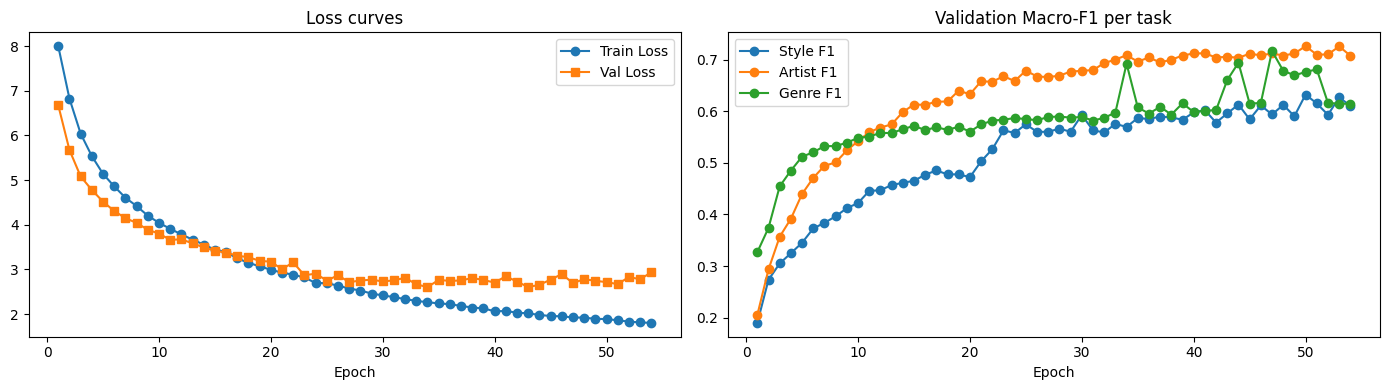

In [15]:
epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs, history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(epochs, history["val_loss"], label="Val Loss", marker="s")
axes[0].set_title("Loss curves")
axes[0].set_xlabel("Epoch")
axes[0].legend()

for task, color in [
    ("style", "tab:blue"),
    ("artist", "tab:orange"),
    ("genre", "tab:green"),
]:
    axes[1].plot(
        epochs,
        history[f"val_f1_{task}"],
        label=f"{task.capitalize()} F1",
        marker="o",
        color=color,
    )
axes[1].set_title("Validation Macro-F1 per task")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 8. Evaluation on Test Set

In [16]:
# Load best checkpoint and evaluate on test set
if CKPT_PATH.exists():
    model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

test_loss, test_accs, test_f1s, test_preds, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)

print("\n── Test Results ──────────────────────────────────")
for task in ["style", "artist", "genre"]:
    print(
        f"  {task.capitalize():8s} | Acc: {test_accs[task]:.4f} | Macro-F1: {test_f1s[task]:.4f}"
    )

eval :   0%|          | 0/13 [00:00<?, ?it/s]


── Test Results ──────────────────────────────────
  Style    | Acc: 0.6868 | Macro-F1: 0.5680
  Artist   | Acc: 0.7385 | Macro-F1: 0.7274
  Genre    | Acc: 0.7083 | Macro-F1: 0.6068


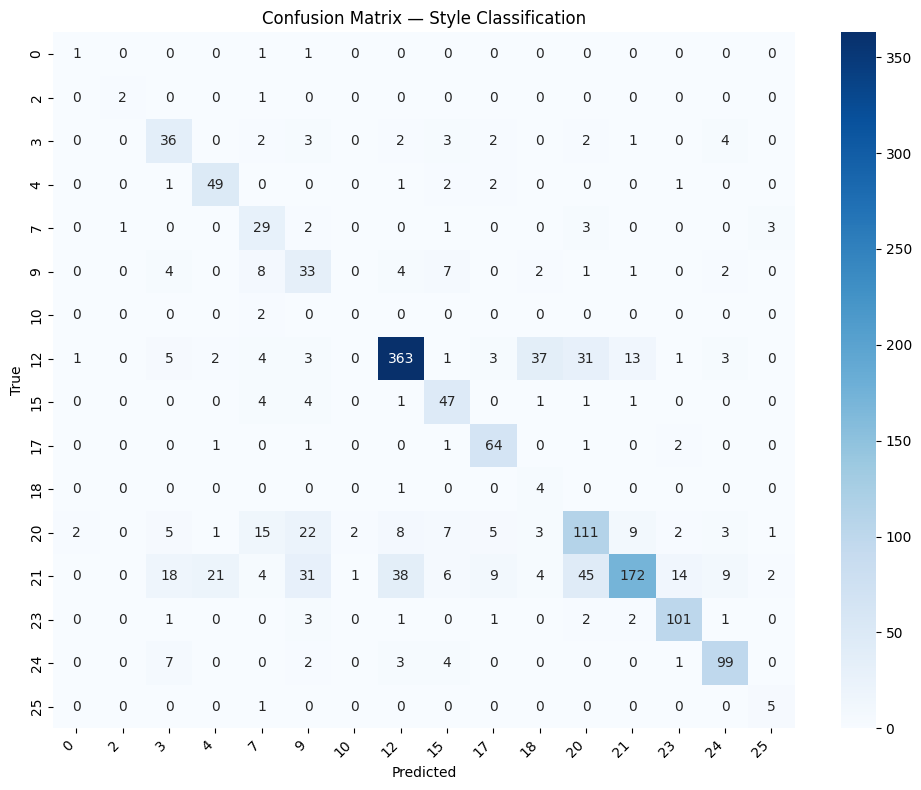


Classification Report (Style):
              precision    recall  f1-score   support

           0       0.25      0.33      0.29         3
           2       0.67      0.67      0.67         3
           3       0.47      0.65      0.55        55
           4       0.66      0.88      0.75        56
           7       0.41      0.74      0.53        39
           9       0.31      0.53      0.40        62
          10       0.00      0.00      0.00         2
          12       0.86      0.78      0.82       467
          15       0.59      0.80      0.68        59
          17       0.74      0.91      0.82        70
          18       0.08      0.80      0.14         5
          20       0.56      0.57      0.56       196
          21       0.86      0.46      0.60       374
          23       0.83      0.90      0.86       112
          24       0.82      0.85      0.84       116
          25       0.45      0.83      0.59         6

    accuracy                           0.69     

In [17]:
# ── Confusion matrix for Style classification ─────────────────────────────────
cm_style = confusion_matrix(test_labels["style"], test_preds["style"])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_style,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_style.classes_,
    yticklabels=le_style.classes_,
    ax=ax,
)
ax.set_title("Confusion Matrix — Style Classification")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nClassification Report (Style):")
print(
    classification_report(
        test_labels["style"],
        test_preds["style"],
        target_names=[str(c) for c in le_style.classes_],
        zero_division=0,
    )
)

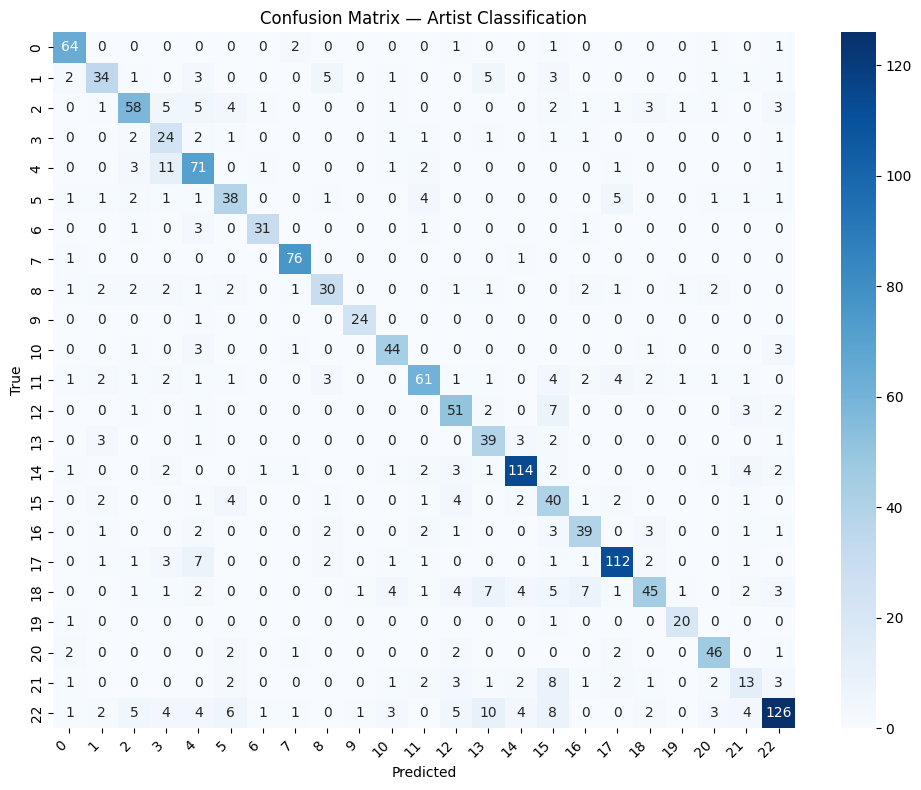


Classification Report (Artist):
              precision    recall  f1-score   support

           0       0.84      0.91      0.88        70
           1       0.69      0.60      0.64        57
           2       0.73      0.67      0.70        87
           3       0.44      0.69      0.53        35
           4       0.65      0.78      0.71        91
           5       0.63      0.67      0.65        57
           6       0.89      0.84      0.86        37
           7       0.92      0.97      0.94        78
           8       0.68      0.61      0.65        49
           9       0.92      0.96      0.94        25
          10       0.76      0.83      0.79        53
          11       0.78      0.69      0.73        89
          12       0.67      0.76      0.71        67
          13       0.57      0.80      0.67        49
          14       0.88      0.84      0.86       135
          15       0.45      0.68      0.54        59
          16       0.70      0.71      0.70     

In [18]:
# ── Confusion matrix for Artist classification ─────────────────────────────────
cm_artist = confusion_matrix(test_labels["artist"], test_preds["artist"])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_artist,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_artist.classes_,
    yticklabels=le_artist.classes_,
    ax=ax,
)
ax.set_title("Confusion Matrix — Artist Classification")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nClassification Report (Artist):")
print(
    classification_report(
        test_labels["artist"],
        test_preds["artist"],
        target_names=[str(c) for c in le_artist.classes_],
        zero_division=0,
    )
)

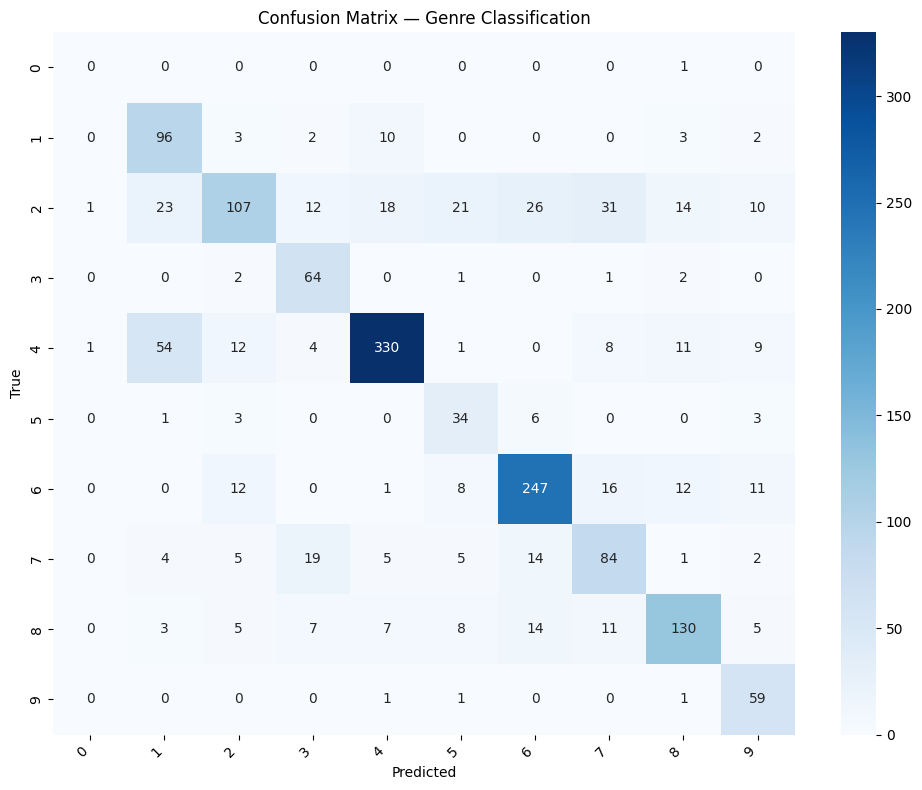


Classification Report (Genre):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.53      0.83      0.65       116
           2       0.72      0.41      0.52       263
           3       0.59      0.91      0.72        70
           4       0.89      0.77      0.82       430
           5       0.43      0.72      0.54        47
           6       0.80      0.80      0.80       307
           7       0.56      0.60      0.58       139
           8       0.74      0.68      0.71       190
           9       0.58      0.95      0.72        62

    accuracy                           0.71      1625
   macro avg       0.58      0.67      0.61      1625
weighted avg       0.74      0.71      0.71      1625



In [19]:
# ── Confusion matrix for Genre classification ─────────────────────────────────
cm_genre = confusion_matrix(test_labels["genre"], test_preds["genre"])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_genre,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_genre.classes_,
    yticklabels=le_genre.classes_,
    ax=ax,
)
ax.set_title("Confusion Matrix — Genre Classification")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nClassification Report (Genre):")
print(
    classification_report(
        test_labels["genre"],
        test_preds["genre"],
        target_names=[str(c) for c in le_genre.classes_],
        zero_division=0,
    )
)

---
## 9. Summary & Discussion

### Architecture choices
| Design decision | Rationale |
|---|---|
| VGG16 backbone | Strong feature extraction for visual tasks; widely used baseline architecture |
| Bi-LSTM over spatial patches | Captures horizontal AND vertical context across image regions |
| Attention pooling | Lets the model focus on the most discriminative patches |
| Multi-task learning | Shared representation improves all three tasks; related attributes regularise each other |
| Uncertainty-weighted loss | Handles different difficulty levels across style / artist / genre |

### Evaluation metrics
| Metric | Why relevant |
|---|---|
| **Top-1 / Top-5 Accuracy** | Standard benchmark — matches ArtGAN paper |
| **Macro F1-Score** | Robust to class imbalance (very skewed artist distribution) |
| **Confusion Matrix** | Reveals systematic confusions (e.g. Impressionism ↔ Post-Impressionism) |


### Expected performance (WikiArt full dataset)
- Style accuracy: ~75–80 % (competitive with state-of-the-art CNN baselines)
- Artist accuracy: ~60–70 % (harder due to 195 artists with few examples each)
- Genre accuracy: ~80–85 % (fewer classes, cleaner signal)